# Recommender system

### Features:
* users' raitings
* watched films
* films similarity

In [31]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path().resolve().parent
DATA_PATH = BASE_DIR / "data/raw/ml-100k"

df = pd.read_csv(
    DATA_PATH / "u.data",
    encoding="latin-1",
    sep="\t",
    header=None,
    names=["user_id", "movie_id", "rating", "timestamp"],
).drop(["timestamp"], axis=1)

df.head()

,user_id,movie_id,rating
0,196,242,3
1,186,302,3
2,22,377,1
3,244,51,2
4,166,346,1


# Columns count

In [32]:
print(
    f"Number of unique users: {df['user_id'].nunique()}\n"
    f"Number of unique movies: {df['movie_id'].nunique()}\n"
    f"Number of ratings: {len(df)}"
)

Number of unique users: 943
Number of unique movies: 1682
Number of ratings: 100000


# Distribution of ratings

Mean rating: 3.52986
Median rating: 4.0


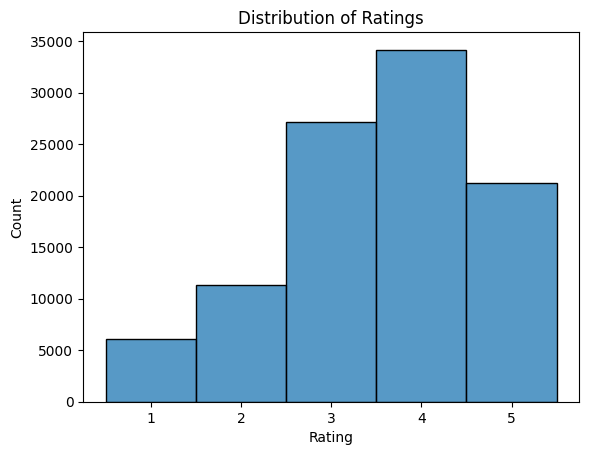

In [33]:
import seaborn as sns

ax = sns.histplot(
    df["rating"],
    bins=5,
    discrete=True,
)
ax.set_title("Distribution of Ratings")
ax.set_xlabel("Rating")

print("Mean rating:", df["rating"].mean())
print("Median rating:", df["rating"].median())

Распределение рейтингов смещено в сторону высоких оценок.

Средний рейтинг составляет 3.53, медианный — 4.0, – пользователи склонны ставить положительные оценки.

Наиболее частая оценка — 4, низкие оценки встречаются значительно реже. Это указывает на дисбаланс в распределении рейтингов и наличие позитивного сдвига.

В итоге, отсутствие рейтинга нельзя интерпретировать как негативную обратную связь (пользователь может не захотеть ставить оценку, даже если фильм понравился).

Следовательно:
- RMSE/MAE не являются основными метриками качества
- implicit-feedback подходы могут работать лучше
- precision и recall больше подходят для оценки

# Ratings stats per user

In [34]:
ratings_per_user = df.groupby("user_id")["rating"].count()

ratings_per_user.describe()

count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
Name: rating, dtype: float64

1. Медиана = 65, среднее = 106, датасет очень наоднороден, с правосторонней симметрией
2. Max = 737, очень активный пользователь, такие будут доминировать в обучении, может понадобиться нормализация, взвешивание или клиппинг
3. Min = 20, очень хорошо, на практике всегда меньше
4. Подойдут: user-based / item-based CF, SVD, ALS
5. std = 100 – активность юзеров очень вариативна -> нужна аккуратная оценка
6. Нужен user-aware сплит
7.

In [36]:
ratings_per_movie = df.groupby("movie_id")["rating"].count()

ratings_per_movie.describe()

count    1682.000000
mean       59.453032
std        80.383846
min         1.000000
25%         6.000000
50%        27.000000
75%        80.000000
max       583.000000
Name: rating, dtype: float64

1. mean = 59, median = 27, есть немного очень популярных фильмов, большинство фильмов имеют мало оценок -> Long-tail items distribution -> модель будет часто рекомендовать самые популярные фильмы
2. 25% фильмов имеют до 6 оценок, для них CF плох, сходство будет шумным, эмбеддинги нестабильны
3. Min = 1, некоторые фильмы почти неизвестны, CF не поможет оценивать такие фильмы
4. Для MVP подойдёт TF-IDF, так как он используюе метаданные
5. В идеале гибридная система, популярные фильмы через CF, редкие через content-based filtering

In [38]:
sparcity = 1 - (len(df) / (df["user_id"].nunique() * df["movie_id"].nunique()))
sparcity

0.9369533063577546